# Preamble

In [1]:
from matplotlib import pyplot as plt # plotting
import math
import sklearn
#import GPy
#np.random.seed(101)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process import kernels
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ExpSineSquared, ConstantKernel, DotProduct, Matern, RationalQuadratic
from sklearn.cluster import KMeans
import optuna

import scipy
from tqdm import tqdm
#import pytorch as torch
import numpy as np
import gymnasium as gym
import gym_unbalanced_disk, time


def rbf(x1,x2,width):
    return np.exp(-0.5* (x1-x2)**2/width)

def demonstrate(full_range,y1,f,var,indices,name):
    plt.figure(figsize=(16,4.8))
    plt.title(name)
    plt.plot(full_range,y1,label="Data",marker=".")
    plt.plot(full_range[indices],f,label="Prediction")
    plt.fill_between(full_range[indices],f+var,f-var,alpha=0.3,label='est std out')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid()
    plt.show()
    return

def demonstrate_alternate(part_range, y1,f,var, name):
    plt.figure(figsize=(16,4.8))
    plt.title(name)
    plt.plot(part_range,y1,label="Data")
    plt.plot(part_range,f,label="Prediction")
    plt.fill_between(part_range,f+var,f-var,alpha=0.3,label='est std out')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid()
    plt.savefig(f'{name}.png')
    plt.show()
    
    return

def quick_plot(full_range,f,var,name):
    plt.figure(figsize=(16,4.8))
    plt.title(name)
    plt.plot(full_range,f,label="Prediction")
    plt.fill_between(full_range,f+var,f-var,alpha=0.3,label='est std out')
    plt.xlabel('x')
    plt.ylabel('f')
    plt.legend()
    plt.grid()
    plt.show()
    return

def quick_plot_alternative(full_range,f,var,index,name):
    plt.figure(figsize=(16,4.8))
    plt.title(name)
    plt.plot(full_range,f,label="Prediction")
    plt.fill_between(full_range,f+var,f-var,alpha=0.3,label='est std out')
    plt.xlabel('x')
    plt.ylabel('f')
    plt.legend()
    plt.grid()
    plt.show()
    return

def state_prep(data, time, order):
        time += 1
        entries = np.min([time,order])
        state = np.zeros((order,2))
        state[(order-entries):order,:] = data[(time-entries):time,:]
        return np.concat((state[:,0].reshape(1,order),state[:,1].reshape(1,order)),axis=1)

def state_prep_loop(data, order):
    states = np.zeros((len(data),2*order))
    for time in range(len(data)): states[time] = state_prep(data, time, order)
    return states

# Bayseian committee machine

In [2]:
def BCM_predict(x22,reg_bcm, use_norm=False, norm=None, supress_nan=True, augmentation_data=np.array([False])):#, norm_y = None):
    #Data augmentation for improved predictions (test)
    if augmentation_data.any():
        x22 = np.concat((x22,augmentation_data),axis=0)

    t_bcm = x22.shape[0]
    prediction_blocks = len(reg_bcm)

    #Initialisation
    f_bcm = np.array(np.zeros([t_bcm, prediction_blocks]))
    f_bcm_run = np.array(np.zeros(t_bcm))
    var_bcm = f_bcm
    precision = np.array(np.zeros([t_bcm, prediction_blocks]))
    precision_run = np.array(np.zeros([t_bcm]))

    #accumulating and combining predictions
    for i in range(prediction_blocks):
        f_bcm[:,i], precision[:,i] = reg_bcm[i].predict(x22,return_std=True)
        
        #sanity checker ignores the results from experts giving NaN or divide by 0 outputs
        if (precision[:,i].all()>0) and (f_bcm[:,i].all() == f_bcm[:,i].all()): 
            precision[:,i] = precision[:,i]**-1
        else: 
            f_bcm[:,i], precision[:,i] = 0, 0
            prediction_blocks += -1             #This accounts for the reduced number of experts for confidence calculations
        
        precision_run = precision_run + precision[:,i]
        f_bcm_run = f_bcm_run + precision[:,i]*f_bcm[:,i]

    
    #precision_run = precision_run**(1/beta)
    #print(precision_run)
    #K22_factor = np.diag(np.linalg.inv(reg_bcm[0].kernel_(x22)))
    
    K22_factor = np.ones(t_bcm)

    cov_bcm = ( -(prediction_blocks-1)*(K22_factor) + precision_run)**-1

    var_bcm = cov_bcm
    f_bcm = (cov_bcm*f_bcm_run)
    
    if augmentation_data.any():
        f_bcm = f_bcm[0]
        var_bcm = var_bcm[0]
    #f_bcm = f_bcm/np.std(f_bcm)

    #mod f_bcm
    #if use_norm: f_bcm = f_bcm%(np.sign(f_bcm)*math.pi)

    #if task_mode: return f_bcm#*norm_y
    return f_bcm, var_bcm#/np.std(f_bcm)

def BCM_train(x1,y1,ker_bcm,p_bcm,N,n_restarts_optimizer=10, labels=np.array([False])):
    #yeah it's training idk
    reg_bcm = np.zeros([p_bcm],dtype='object')

    #labels = quick_cluster(x1,y1,p_bcm)
    
    for p in tqdm(range(p_bcm)):
        #x11 = x1[np.mod(np.array(range(N))+p,p_bcm)==0]
        #y11 = y1[np.mod(np.array(range(N))+p,p_bcm)==0]
        
        if labels.any():
            x11 = x1[labels==p]
            y11 = y1[labels==p]
        else:
            x11 = x1[int(p*N/p_bcm):int((p+1)*N/p_bcm)]
            y11 = y1[int(p*N/p_bcm):int((p+1)*N/p_bcm)]

        #x11 = x1[labels == p]
        #y11 = y1[labels == p]
        
        reg_bcm[p] = GaussianProcessRegressor(ker_bcm,alpha=10**-6, n_restarts_optimizer=n_restarts_optimizer, normalize_y=True) #a=)
        reg_bcm[p].fit(x11,y11) #a)
    return reg_bcm

def quick_cluster(x,y, num):
    kmeans = KMeans(n_clusters=num, random_state=0, n_init="auto")
    kmeans.fit(x)
    labels = kmeans.labels_
    return labels


# Own BCM training

In [3]:
N=30000
V=5000

full_range = range(N+V)

readout = np.loadtxt('/home/sodium-nitrate/aur/gym-unbalanced-disk/disc-benchmark-files/training-val-test-data.csv',delimiter=',',dtype=float)

readout_u = readout[:,0]
readout_y = readout[:,1]


#norm_u = (np.max(readout_u ) - np.min(readout_u ))
#norm_y = (np.max(readout_y ) - np.min(readout_y ))

norm_u = np.std(readout_u)
norm_y = np.std(readout_y)

mean_u = np.mean(readout_u)
mean_y = np.mean(readout_y)

readout_u_tra = readout_u[:N]
readout_y_tra = readout_y[:N]

readout_u_val = readout_u[N:]
readout_y_val = readout_y[N:]

order = 5


x_tra = state_prep_loop(np.concat((readout_u_tra[:,None],readout_y_tra[:,None]),axis=1), order)
y_tra = readout_y_tra[:,None]

x_val = state_prep_loop(np.concat((readout_u_val[:,None],readout_y_val[:,None]),axis=1), order)
y_val = readout_y_val[:,None]


range_tra = np.array(range(N))
range_val = np.array(range(V))

kernel = rbf

#print(readout_u_val)
#print(readout_y_val)
#print(x_val)


In [ ]:
# Setup

kernel = rbf
width_bcm = 0.5
noise_bcm = 0.1

p_bcm = 190 #no of partitions
M_bcm = 350 #partition block size

N_div = 40
V_div = 1

testpoints_ind_bcm = (np.mod(range(N),N_div)==0)
valipoints_ind_bcm = (np.mod(range(V),V_div)==0)


x_test = x_tra[testpoints_ind_bcm,:]
y_test = y_tra[testpoints_ind_bcm,:]

x_vali = x_val[valipoints_ind_bcm,:]
y_vali = y_val[valipoints_ind_bcm,:]

initial_length_scales = np.ones(2*order)*0.5

ker_bcm =  WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-6, 1e1)) + Matern(length_scale=initial_length_scales, nu=2.5)  + ConstantKernel(constant_value_bounds=(0.01,10))*ExpSineSquared(length_scale=0.5,periodicity=0.5) #DotProduct()   #a=)


In [ ]:
## Training
#bcm_start = time.time()
#
reg_bcm_pred = BCM_train(x_tra,y_tra,ker_bcm,p_bcm,N)
#
#bcm_end = time.time()
#bcm_run = bcm_end - bcm_start

In [ ]:
#f_bcm_test,var_bcm_test = BCM_predict(x_test,reg_bcm,kernel,width_bcm)
#test_rmse = sklearn.metrics.root_mean_squared_error(y_test, f_bcm_test)*norm_y
#
#f_bcm_vali,var_bcm_vali = BCM_predict(x_vali,reg_bcm,kernel,width_bcm)
#vali_rmse = sklearn.metrics.root_mean_squared_error(y_vali, f_bcm_vali)*norm_y

#for p in range(p_bcm): print(reg_bcm[p].kernel_)
#
#name = 'BCM GP with ' + str(p_bcm) + " partitions and " + str(int(N/N_div)) + " test block size"
#demonstrate(range_tra,y_tra,f_bcm_test,var_bcm_test,testpoints_ind_bcm,name)
#
#name = 'BCM GP with ' + str(p_bcm) + " partitions and " + str(int(V/V_div)) + " validation block size"
#demonstrate(range_val,y_val,f_bcm_vali,var_bcm_vali,valipoints_ind_bcm,name)
#
#print("test RMSE: ", test_rmse, "\n","validation RMSE: ", vali_rmse )

#print("Log-marginal-likelihood:", reg_bcm[0].log_marginal_likelihood_value_)
#print("Log-marginal-likelihood:", reg_bcm[0].kernel_)

# Predictions task

In [ ]:

data = np.load('/home/sodium-nitrate/aur/gym-unbalanced-disk/disc-benchmark-files/hidden-test-prediction-submission-file.npz')
upast_test = data['upast'] #N by u[k-15],u[k-14],...,u[k-1]
thpast_test = data['thpast'] #N by y[k-15],y[k-14],...,y[k-1]
Xtest = np.concatenate([upast_test[:,15-order:15], thpast_test[:,15-order:15]],axis=1)

#Ypredict, Varpredict = reg_bcm[0].predict(Xtest,return_std=True)
Ypredict, Varpredict = BCM_predict(Xtest,reg_bcm_pred,kernel,width_bcm)

np.savez('NITIN-hidden-test-prediction-example-submission-file.npz', upast=upast_test, thpast=thpast_test, thnow=Ypredict)

quick_plot(range(len(Xtest)),Ypredict,Varpredict,'predictions idk')


# Optuna study

In [782]:
study = optuna.create_study(direction='minimize', storage='sqlite:///example.db', load_if_exists=True)

V = 5000

out = np.load('training-val-test-data.npz')
th_train = out['th'] #th[0],th[1],th[2],th[3],...
u_train = out['u'] #u[0],u[1],u[2],u[3],...

th_val_target = th_train[:V]
u_val_target = u_train[:V]

th_train = th_train[V:]
u_train =  u_train[V:]

# Downsampling for speed
th_train = th_train[ np.mod(range(len(th_train)),5) == 0 ]
u_train =  u_train[  np.mod(range(len(u_train)), 5) == 0 ]

predict_handler = lambda x: (BCM_predict(x,reg_bcm))

def simulate_handler(x, reg_bcm):
    return np.squeeze(BCM_predict(x[None,:],reg_bcm,use_mod=True)[0]), np.squeeze(BCM_predict(x[None,:],reg_bcm,use_mod=True,)[1])


def simulation_IO_model(f, reg, ulist, ylist, na, nb, skip=50):
    
    upast = ulist[skip-nb:skip].tolist() #good initialization
    ypast = ylist[skip-na:skip].tolist()
    Y = ylist[:skip].tolist()
    var = []
    for u in tqdm(ulist[skip:]):
        #print(u)
        x = np.concatenate([upast,ypast],axis=0)
        ypred, v = f(x, reg)
        var.append(v)
        Y.append(ypred)
        upast.append(u)
        upast.pop(0)
        ypast.append(ypred)
        ypast.pop(0)
    return np.array(Y), np.concat((np.zeros(max(na,nb)),np.array(var)))


[I 2026-06-16 00:35:57,933] A new study created in RDB with name: no-name-0e68bf14-bec1-4a8e-bd2f-da462c24d9b1


In [783]:

def objective(trial):

    # 2. Suggest values of the hyperparameters using a trial object.
    na = trial.suggest_int("na", 1, 10)
    nb = trial.suggest_int("nb", 1, 10)
    nu = trial.suggest_int("nu", 1, 2) + 0.5

    #na = 5
    #nb = 5

    user_matern = trial.suggest_categorical("matern", [False, True])
    user_rbf    = trial.suggest_categorical("rbf",    [False, True])
    user_rq     = trial.suggest_categorical("rq",     [False, True])
    user_exps   = trial.suggest_categorical("exps",   [False, True])

    #user_matern = False
    #user_rbf    = True
    #user_rq     = True
    #user_exps   = False


    #p_bcm = trial.suggest_int("p_bcm", 1, 5)*10
    p_bcm = 40

    Xtrain, Ytrain = create_IO_data(u_train, th_train, na, nb)
    Xval_target, Yval_target = create_IO_data(u_val_target, th_val_target, na, nb)

    initial_length_scales = np.ones(na+nb)*0.5

    ker_bcm =  WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-6, 1e1))
    if user_matern: ker_bcm = ker_bcm + ConstantKernel(constant_value_bounds=(0.01,1))*Matern(length_scale=initial_length_scales, nu=2.5)
    if user_rbf   : ker_bcm = ker_bcm + ConstantKernel(constant_value_bounds=(0.01,1))*RBF(length_scale=initial_length_scales)
    if user_rq    : ker_bcm = ker_bcm + ConstantKernel(constant_value_bounds=(0.01,1))*RationalQuadratic(length_scale=0.5, alpha=1.5)
    if user_exps  : ker_bcm = ker_bcm + ConstantKernel(constant_value_bounds=(0.01,1))*ExpSineSquared(length_scale=0.5, periodicity=0.5)

    #len(Ytrain)

    reg_bcm = BCM_train(Xtrain,Ytrain,ker_bcm,p_bcm,len(Ytrain),n_restarts_optimizer=10)

    skip = max(na,nb)
    th_opt_sim, var_opt_sim = simulation_IO_model(f=simulate_handler, reg=reg_bcm, ulist=u_val_target, ylist=th_val_target[:50], na=na, nb=nb, skip=skip)
    
    return np.mean((th_val_target[skip:]-th_opt_sim[skip:])**2)**0.5

# 3. Create a study object and optimize the objective function.



In [785]:
study.optimize(objective, n_trials=300)

print(study.best_params)

100%|██████████| 4991/4991 [01:04<00:00, 77.63it/s]
[I 2026-06-16 00:43:26,204] Trial 1 finished with value: 0.5221716644323194 and parameters: {'na': 9, 'nb': 5, 'nu': 1, 'matern': True, 'rbf': True, 'rq': False, 'exps': True}. Best is trial 1 with value: 0.5221716644323194.
100%|██████████| 4992/4992 [00:54<00:00, 91.97it/s]
[I 2026-06-16 00:45:26,073] Trial 2 finished with value: 0.6248629338256607 and parameters: {'na': 1, 'nb': 8, 'nu': 2, 'matern': True, 'rbf': False, 'rq': False, 'exps': True}. Best is trial 1 with value: 0.5221716644323194.
100%|██████████| 4993/4993 [01:00<00:00, 82.99it/s]
[I 2026-06-16 00:48:37,438] Trial 3 finished with value: 0.5235874603565509 and parameters: {'na': 2, 'nb': 7, 'nu': 1, 'matern': True, 'rbf': True, 'rq': False, 'exps': True}. Best is trial 1 with value: 0.5221716644323194.
100%|██████████| 4992/4992 [00:52<00:00, 95.58it/s]
[I 2026-06-16 00:50:58,633] Trial 4 finished with value: 0.5202262817470077 and parameters: {'na': 4, 'nb': 8, 'nu':

{'na': 1, 'nb': 1, 'nu': 2, 'matern': False, 'rbf': False, 'rq': False, 'exps': False}


In [789]:
if np.array([1,2,3]): print(4)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [786]:
print(study.best_params)
print(study.best_value)


{'na': 1, 'nb': 1, 'nu': 2, 'matern': False, 'rbf': False, 'rq': False, 'exps': False}
0.491570539635734


# Simulations task P.1

In [ ]:
#Training data maker



V = 5000

out = np.load('training-val-test-data.npz')
th_train = (out['th']) #th[0],th[1],th[2],th[3],...
u_train = out['u'] #u[0],u[1],u[2],u[3],...

#th_train = th_train/np.std(th_train)
#u_train = u_train/np.std(u_train)


th_val_target = th_train[:V]
u_val_target = u_train[:V]

th_train = th_train[V:]
u_train =  u_train[V:]

def create_IO_data(u,y,na,nb):
    X = []
    Y = []
    for k in range(max(na,nb), len(y)):
        X.append(np.concatenate([u[k-nb:k],y[k-na:k]]))
        Y.append(y[k])
    return np.array(X), np.array(Y)

na = 5
nb = 5

Xtrain, Ytrain = create_IO_data(u_train, th_train, na, nb)
Xval_target, Yval_target = create_IO_data(u_val_target, th_val_target, na, nb)

#######################################################################################
p_bcm = 100 #no of partitions
M_bcm = 300


from sklearn.cluster import KMeans
labels = KMeans(n_clusters=p_bcm, random_state=0, n_init="auto").fit(Xtrain).labels_

#Xtrain_process = Xtrain
#Ytrain_process = Ytrain
#
#for i in range(p_bcm):
#    Xtrain_process[i*M_bcm:((i+1)*M_bcm)] = Xtrain[kmeans.labels_ == i]
#    Ytrain_process[i*M_bcm:((i+1)*M_bcm)] = Ytrain[kmeans.labels_ == i]
#
#Xtrain = Xtrain_process
#Ytrain = Ytrain_process

print(Xtrain)
print(Xval_target)


[[ 0.37031887  0.52658785  0.61728572 ... -0.22305308 -0.169646
  -0.09424778]
 [ 0.52658785  0.61728572  0.65182393 ... -0.169646   -0.09424778
  -0.00314159]
 [ 0.61728572  0.65182393  0.64811581 ... -0.09424778 -0.00314159
   0.09424778]
 ...
 [-0.35520163 -0.28917482 -0.19323627 ...  0.02513274 -0.02513274
  -0.07225663]
 [-0.28917482 -0.19323627 -0.08630892 ... -0.02513274 -0.07225663
  -0.10995574]
 [-0.19323627 -0.08630892  0.01058221 ... -0.07225663 -0.10995574
  -0.1288053 ]]
[[ 0.16029299 -0.02893118 -0.27235568 ...  0.          0.
   0.        ]
 [-0.02893118 -0.27235568 -0.53273637 ...  0.          0.
  -0.00314159]
 [-0.27235568 -0.53273637 -0.76769229 ...  0.         -0.00314159
  -0.00628319]
 ...
 [-1.31002474 -1.292566   -1.17895633 ...  0.02827433 -0.01570796
  -0.07225663]
 [-1.292566   -1.17895633 -0.97989567 ... -0.01570796 -0.07225663
  -0.13194689]
 [-1.17895633 -0.97989567 -0.71721069 ... -0.07225663 -0.13194689
  -0.19163715]]


In [ ]:
########## MY SOLUTION


initial_length_scales = np.ones(na+nb)*0.5


use_matern  = True
use_rbf     = True
use_rq      = False
use_exps    = False
use_product = False

ker_bcm =  WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-6, 1e1))
if use_matern: ker_bcm = ker_bcm + Matern(length_scale=initial_length_scales, nu=2.5)*ConstantKernel(constant_value_bounds=(0.01,1))
if use_rbf   : ker_bcm = ker_bcm + RBF(length_scale=initial_length_scales)#*ConstantKernel(constant_value_bounds=(0.01,1))
if use_rq    : ker_bcm = ker_bcm + ConstantKernel(constant_value_bounds=(0.01,1))*RationalQuadratic(length_scale=0.5, alpha=1.5)
if use_exps  : ker_bcm = ker_bcm + ConstantKernel(constant_value_bounds=(0.01,1))*ExpSineSquared(length_scale=0.5, periodicity=0.5)
if use_product  : ker_bcm = ker_bcm + ConstantKernel(constant_value_bounds=(0.01,1))*ExpSineSquared(length_scale=0.5, periodicity=0.5)*RBF(length_scale=initial_length_scales)



reg_bcm = BCM_train(Xtrain,Ytrain,ker_bcm,p_bcm,len(Ytrain),n_restarts_optimizer=10,labels=labels)

########## MY SOLUTION

  0%|          | 0/200 [00:00<?, ?it/s]/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 8 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling f

KeyboardInterrupt: 

WhiteKernel(noise_level=2.21e-05) + Matern(length_scale=[1.92, 0.000409, 76.4, 0.00214, 1.65e-05, 1.82e-05, 0.000121, 915, 264, 12.5], nu=2.5) + 3.16**2 * ExpSineSquared(length_scale=0.00241, periodicity=1.71e+04)
WhiteKernel(noise_level=0.000139) + Matern(length_scale=[199, 19.5, 39.2, 290, 423, 2.4, 4.24, 1.11e+03, 1.75, 7.19e+03], nu=2.5) + 0.11**2 * ExpSineSquared(length_scale=94.1, periodicity=1.61)
WhiteKernel(noise_level=5.05e-05) + Matern(length_scale=[1e+05, 2.65e+04, 103, 80.3, 7.51e+04, 1.82e+03, 2.13e+03, 9.51e+04, 1.96, 1.39], nu=2.5) + 0.1**2 * ExpSineSquared(length_scale=4.34e+04, periodicity=8.12e+04)
WhiteKernel(noise_level=5.71e-05) + Matern(length_scale=[2.11e+03, 2.42e+03, 1e+05, 317, 242, 1.07e+04, 29.9, 1.37e+04, 1.73e+04, 92], nu=2.5) + 3.16**2 * ExpSineSquared(length_scale=0.296, periodicity=145)
WhiteKernel(noise_level=4.51e-05) + Matern(length_scale=[1e+05, 2.26e+04, 40.7, 1.4e+04, 1e+05, 5.61e+04, 5.11, 4.75, 2.65e+03, 1.99], nu=2.5) + 0.1**2 * ExpSineSquared

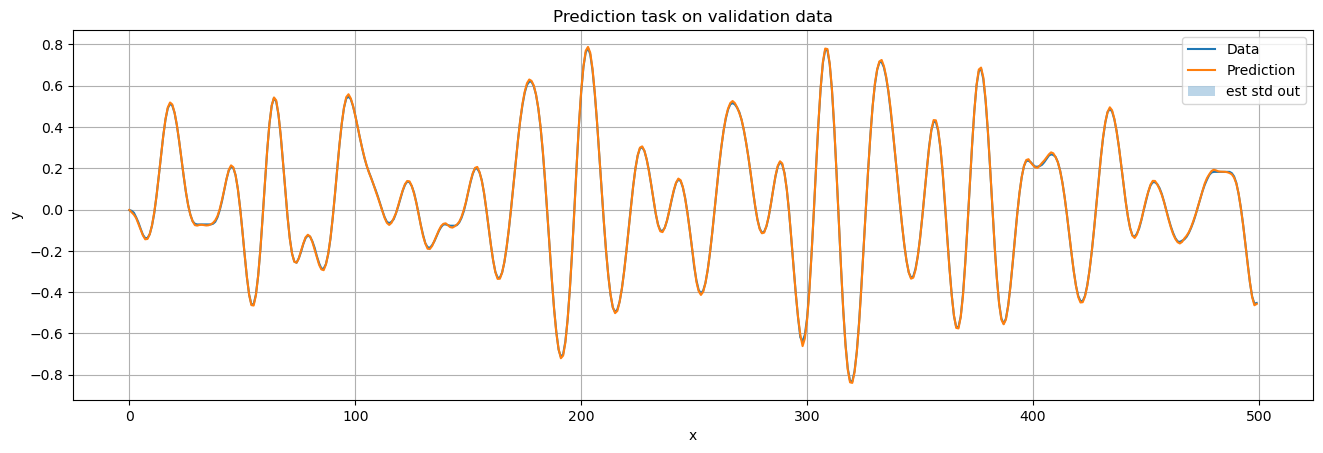

In [ ]:
predict_handler = lambda x: (BCM_predict(x,reg_bcm))

def simulate_handler(x):
    return np.squeeze(BCM_predict(x[None,:],reg_bcm,use_norm=True)[0]), \
           np.squeeze(BCM_predict(x[None,:],reg_bcm,use_norm=True)[1])

for p in range(p_bcm): print(reg_bcm[p].kernel_)

indices_pred = np.array(range(len(Xval_target)))<500      #Predict on only 500 points to save time

part_range = np.array(range(500))

Ytrain_pred, var_train_pred = predict_handler(Xval_target[indices_pred]) 

demonstrate_alternate(part_range, Yval_target[indices_pred], Ytrain_pred , var_train_pred , f"Prediction_against_validation_w_sampling_inputs_(na, nb)=({na},{nb})_partitions={p_bcm}")


# Simulation task P.2 

In [ ]:
data = np.load('hidden-test-simulation-submission-file.npz')
u_test = data['u']
th_test = data['th'] #only the first 50 values are filled the rest are zeros


#norm_th = np.std(th_test)
#norm_u = np.std(u_test)

#u_test, th_test = u_test/norm_u, th_test/norm_th

#print(norm_x)
#print(norm_y)

def simulation_IO_model(f, ulist, ylist, skip=50):
    
    upast = ulist[skip-nb:skip].tolist() #good initialization
    ypast = ylist[skip-na:skip].tolist()
    Y = ylist[:skip].tolist()
    var = []
    for u in tqdm(ulist[skip:]):
        #print(u)
        x = np.concatenate([upast,ypast],axis=0)
        ypred, v = f(x)
        var.append(v)
        Y.append(ypred)
        upast.append(u)
        upast.pop(0)
        ypast.append(ypred)
        ypast.pop(0)
    return np.array(Y), np.concat((np.zeros(max(na,nb)),np.array(var)))




In [ ]:
skip = max(na,nb)

#th_train_sim, var_train_sim = simulation_IO_model(simulate_handler, u_train, th_train, skip=skip)

 
th_val_sim, var_val_sim = simulation_IO_model(simulate_handler, ulist=u_val_target, ylist=th_val_target[:50], skip=skip)


skip = 50

#th_test_sim,  var_test_sim = simulation_IO_model(simulate_handler, u_test, th_test, skip=skip)

#assert len(th_test_sim)==len(th_test)
#np.savez('NITIN-hidden-test-simulation-example-submission-file.npz', th=th_test_sim, u=u_test)


100%|██████████| 6995/6995 [05:53<00:00, 19.78it/s]


28000


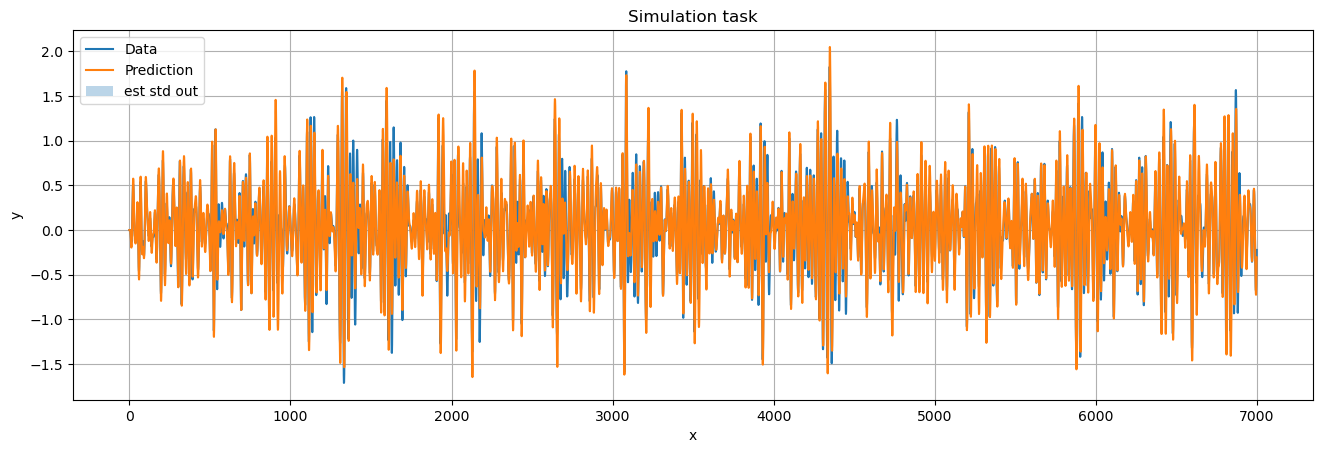

In [ ]:
print(len(th_train))
print(len(full_range[:V]))

demonstrate_alternate(full_range[:5000], th_val_target[:], th_train_sim[:], var_train_sim[:], f"Simulation_against_validation_w_sampling _inputs_(na, nb)=({na},{nb})_partitions={p_bcm}")

# Results

In [ ]:

print('training prediction errors:')
print('RMS:',  np.mean((Yval_target[indices_pred]-Ytrain_pred)**2)**0.5,'radians')
print('RMS:',  np.mean((Yval_target[indices_pred]-Ytrain_pred)**2)**0.5/(2*np.pi)*360,'degrees')
print('NRMS:', np.mean((Yval_target[indices_pred]-Ytrain_pred)**2)**0.5/Ytrain.std()*100,'%')

print('training simulation errors:')
print('RMS:', np.mean((th_train_sim[skip:]-th_val_target[skip:])**2)**0.5,'radians')
print('RMS:', np.mean((th_train_sim[skip:]-th_val_target[skip:])**2)**0.5/(2*np.pi)*360,'degrees')
print('NRMS:', np.mean((th_train_sim[skip:]-th_val_target[skip:])**2)**0.5/th_train.std()*100,'%')

training prediction errors:
RMS: 0.004507488953335022 radians
RMS: 0.25826009322793764 degrees
NRMS: 0.9464212215436905 %
training simulation errors:
RMS: 0.15356002496951288 radians
RMS: 8.798341332676626 degrees
NRMS: 32.24389886861618 %
